In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Carregar os dados
(X_train, y_train_raw), (X_test, y_test_raw) = mnist.load_data()

# 2. Pré-processamento: Redimensionar (flatten) e Normalizar
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# 3. Conversão para One-Hot Encoding
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

print(f"Treino: {X_train.shape}, Rótulos: {y_train.shape}")
print(f"Teste: {X_test.shape}, Rótulos: {y_test.shape}")

I0000 00:00:1780683218.725398  112892 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780683218.729233  112892 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780683218.830713  112892 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780683220.216325  112892 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780683220.216540  112892 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step
Treino: (60000, 784), Rótulos: (60000, 10)
Teste: (10000, 784), Rótulos: (10000, 10)


In [3]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from mlp.network import NeuralNetwork, Dense
from mlp.activations import ReLU, Softmax
from mlp.losses import CategoricalCrossEntropy
from mlp.optimizers import SGD

In [4]:
def train_model(network, loss_fn, optimizer, epochs=15, batch_size=64):
    loss_history = []
    accuracy_history = []
    
    num_samples = X_train.shape[0]
    
    for epoch in range(epochs):
        # Embaralhar os dados a cada época
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        num_batches = int(np.ceil(num_samples / batch_size))
        
        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)
            
            xb = X_shuffled[start_idx:end_idx]
            yb = y_shuffled[start_idx:end_idx]
            
            # 1. Forward Pass
            predictions = network.forward(xb)
            
            # 2. Computar Perda
            loss = loss_fn.forward(predictions, yb)
            epoch_loss += loss * (end_idx - start_idx)
            
            # 3. Backward Pass
            loss_grad = loss_fn.backward()
            network.backward(loss_grad)
            
            # 4. Atualizar Pesos
            optimizer.update(network.layers)
            
        epoch_loss /= num_samples
        loss_history.append(epoch_loss)
        
        # Avaliar acurácia no teste após a época
        test_preds = network.forward(X_test)
        pred_labels = np.argmax(test_preds, axis=1)
        true_labels = np.argmax(y_test, axis=1)
        accuracy = np.mean(pred_labels == true_labels) * 100
        accuracy_history.append(accuracy)
        
        print(f"Época {epoch+1:02d}/{epochs:02d} -> Loss Média: {epoch_loss:.4f} | Acurácia Teste: {accuracy:.2f}%")
        
    return loss_history, accuracy_history

In [5]:
# Inicializando o modelo
mlp_modelo_A = NeuralNetwork()
mlp_modelo_A.add(Dense(input_dim=784, output_dim=128))
mlp_modelo_A.add(ReLU())
mlp_modelo_A.add(Dense(input_dim=128, output_dim=64))
mlp_modelo_A.add(ReLU())
mlp_modelo_A.add(Dense(input_dim=64, output_dim=10))
mlp_modelo_A.add(Softmax())

loss_criterion = CategoricalCrossEntropy()
opt = SGD(learning_rate=0.1)  # LR de 0.1 funciona muito bem para o SGD no MNIST

print("Iniciando Treinamento do Modelo A...")
loss_A, acc_A = train_model(mlp_modelo_A, loss_criterion, opt, epochs=15, batch_size=64)

Iniciando Treinamento do Modelo A...
Época 01/15 -> Loss Média: 0.3392 | Acurácia Teste: 94.05%
Época 02/15 -> Loss Média: 0.1488 | Acurácia Teste: 95.83%
Época 03/15 -> Loss Média: 0.1050 | Acurácia Teste: 96.85%
Época 04/15 -> Loss Média: 0.0826 | Acurácia Teste: 97.46%
Época 05/15 -> Loss Média: 0.0668 | Acurácia Teste: 97.34%
Época 06/15 -> Loss Média: 0.0557 | Acurácia Teste: 97.48%
Época 07/15 -> Loss Média: 0.0478 | Acurácia Teste: 97.64%
Época 08/15 -> Loss Média: 0.0400 | Acurácia Teste: 97.59%
Época 09/15 -> Loss Média: 0.0348 | Acurácia Teste: 97.59%
Época 10/15 -> Loss Média: 0.0289 | Acurácia Teste: 97.48%
Época 11/15 -> Loss Média: 0.0239 | Acurácia Teste: 98.04%
Época 12/15 -> Loss Média: 0.0205 | Acurácia Teste: 97.88%
Época 13/15 -> Loss Média: 0.0170 | Acurácia Teste: 97.76%
Época 14/15 -> Loss Média: 0.0137 | Acurácia Teste: 97.98%
Época 15/15 -> Loss Média: 0.0117 | Acurácia Teste: 97.98%


In [6]:
mlp_modelo_B = NeuralNetwork()
mlp_modelo_B.add(Dense(input_dim=784, output_dim=32)) # Rede bem menor
mlp_modelo_B.add(ReLU())
mlp_modelo_B.add(Dense(input_dim=32, output_dim=16))
mlp_modelo_B.add(ReLU())
mlp_modelo_B.add(Dense(input_dim=16, output_dim=10))
mlp_modelo_B.add(Softmax())

opt_B = SGD(learning_rate=0.01) # Learning rate 10x menor

print("\nIniciando Treinamento do Modelo B...")
loss_B, acc_B = train_model(mlp_modelo_B, loss_criterion, opt_B, epochs=15, batch_size=64)


Iniciando Treinamento do Modelo B...
Época 01/15 -> Loss Média: 1.0585 | Acurácia Teste: 88.02%
Época 02/15 -> Loss Média: 0.3893 | Acurácia Teste: 90.96%
Época 03/15 -> Loss Média: 0.3178 | Acurácia Teste: 91.49%
Época 04/15 -> Loss Média: 0.2825 | Acurácia Teste: 92.44%
Época 05/15 -> Loss Média: 0.2596 | Acurácia Teste: 92.95%
Época 06/15 -> Loss Média: 0.2424 | Acurácia Teste: 93.11%
Época 07/15 -> Loss Média: 0.2281 | Acurácia Teste: 93.44%
Época 08/15 -> Loss Média: 0.2158 | Acurácia Teste: 93.79%
Época 09/15 -> Loss Média: 0.2058 | Acurácia Teste: 94.02%
Época 10/15 -> Loss Média: 0.1967 | Acurácia Teste: 94.35%
Época 11/15 -> Loss Média: 0.1884 | Acurácia Teste: 94.54%
Época 12/15 -> Loss Média: 0.1811 | Acurácia Teste: 94.62%
Época 13/15 -> Loss Média: 0.1742 | Acurácia Teste: 95.05%
Época 14/15 -> Loss Média: 0.1680 | Acurácia Teste: 95.04%
Época 15/15 -> Loss Média: 0.1622 | Acurácia Teste: 95.13%


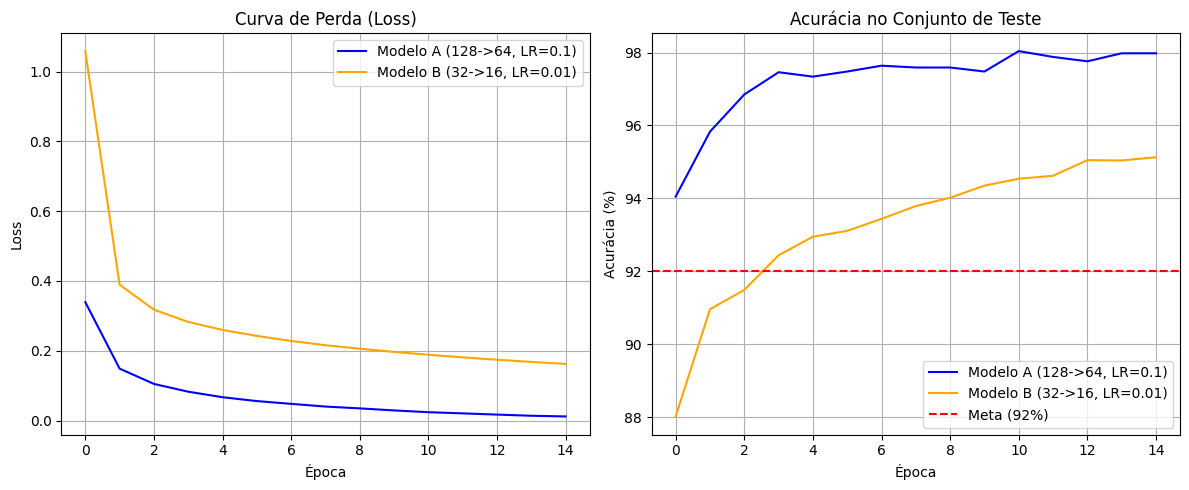

In [7]:
# Criar diretório de resultados se não existir
os.makedirs('../results', exist_ok=True)

plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(loss_A, label='Modelo A (128->64, LR=0.1)', color='blue')
plt.plot(loss_B, label='Modelo B (32->16, LR=0.01)', color='orange')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(acc_A, label='Modelo A (128->64, LR=0.1)', color='blue')
plt.plot(acc_B, label='Modelo B (32->16, LR=0.01)', color='orange')
plt.axhline(y=92, color='r', linestyle='--', label='Meta (92%)')
plt.title('Acurácia no Conjunto de Teste')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../results/curvas_treinamento.png')
plt.show()